In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

esto es con 19.5 mev

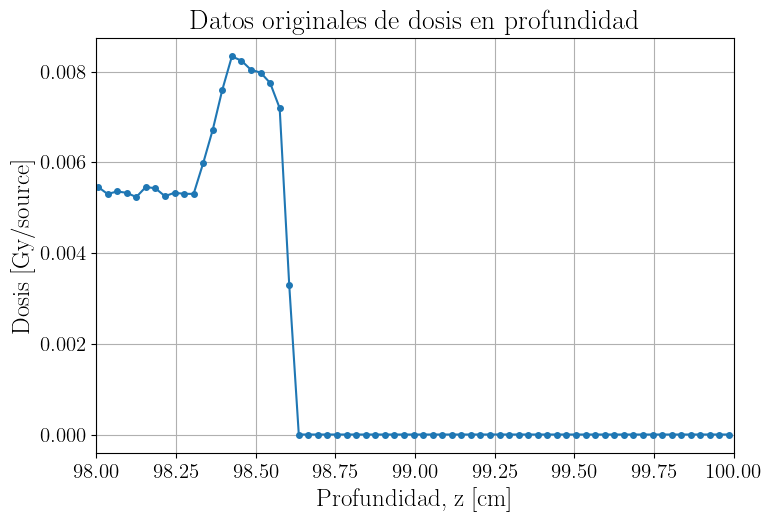

In [5]:


archivo = "bragg_pouch_zL.out"

z = []
dose = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()

        if len(parts) != 4:
            continue

        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
        except ValueError:
            continue

        z.append((z1 + z2) / 2)
        dose.append(d)

z = np.array(z)
dose = np.array(dose)

orden = np.argsort(z)
z = z[orden]
dose = dose[orden]

mascara = (z >= 98.0) & (z <= 100.0)
z = z[mascara]
dose = dose[mascara]

plt.figure(figsize=(8, 5.5))

plt.plot(
    z,
    dose,
    marker="o",
    markersize=4,
    linewidth=1.5
)

plt.xlim(98, 100)
plt.xlabel("Profundidad, z [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Datos originales de dosis en profundidad")
plt.grid(True)
plt.tight_layout()
plt.show()

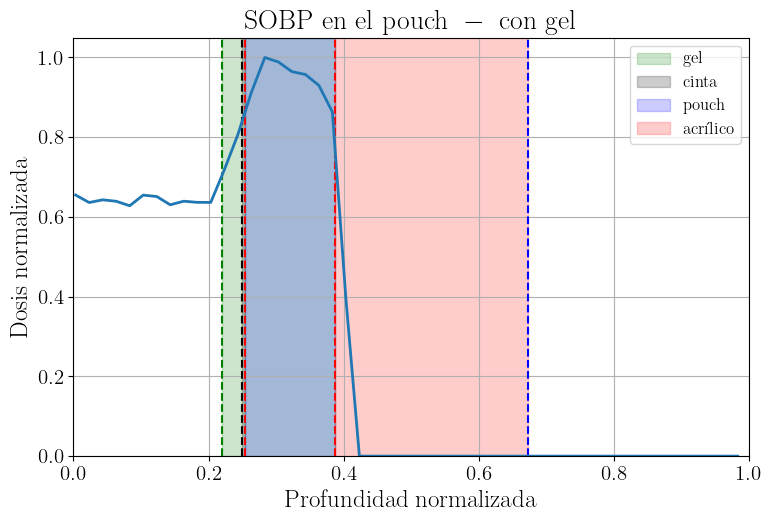

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12
})

archivo = "bragg_pouch_zL.out"

z = []
dose = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()

        if len(parts) != 4:
            continue

        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
        except ValueError:
            continue

        z.append((z1 + z2) / 2)
        dose.append(d)

z = np.array(z)
dose = np.array(dose)

orden = np.argsort(z)
z = z[orden]
dose = dose[orden]

z_min = 98.0
z_max = 99.5

mascara = (z >= z_min) & (z <= z_max)
z = z[mascara]
dose = dose[mascara]

if len(z) == 0:
    raise ValueError("No se encontraron datos entre 98 y 99.5 cm.")

if np.max(dose) <= 0:
    raise ValueError("La dosis máxima es cero y no puede normalizarse.")

z_norm = (z - z_min) / (z_max - z_min)
dose_norm = dose / np.max(dose)

def normalizar_z(valor):
    return (valor - z_min) / (z_max - z_min)

x_gel = normalizar_z(98.33)
x_cinta = normalizar_z(98.375)
x_pouch_min = normalizar_z(98.38)
x_pouch_max = normalizar_z(98.58)
x_acrilico_max = normalizar_z(99.01)

plt.figure(figsize=(8, 5.5))

plt.axvspan(
    x_gel,
    x_pouch_max,
    color="g",
    alpha=0.2,
    label=r"$\mathrm{gel}$"
)

plt.axvspan(
    x_cinta,
    x_pouch_min,
    color="k",
    alpha=0.2,
    label=r"$\mathrm{cinta}$"
)

plt.axvspan(
    x_pouch_min,
    x_pouch_max,
    color="b",
    alpha=0.2,
    label=r"$\mathrm{pouch}$"
)

plt.axvspan(
    x_pouch_max,
    x_acrilico_max,
    color="r",
    alpha=0.2,
    label=r"$\mathrm{acr\acute{\i}lico}$"
)

plt.axvline(x=x_gel, color="g", linestyle="--")
plt.axvline(x=x_cinta, color="k", linestyle="--")
plt.axvline(x=x_pouch_min, color="r", linestyle="--")
plt.axvline(x=x_pouch_max, color="r", linestyle="--")
plt.axvline(x=x_acrilico_max, color="b", linestyle="--")

plt.plot(
    z_norm,
    dose_norm,
    linewidth=2
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.xlabel(r"$\mathrm{Profundidad\ normalizada}$")
plt.ylabel(r"$\mathrm{Dosis\ normalizada}$")
plt.title(r"$\mathrm{SOBP\ en\ el\ pouch\ - \ con\ gel}$")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()